# Homework 10 -- APPM 4600
## Problem 1
![p1](Images/hw%2010-p1.jpeg)
![p2](Images/hw%2010-p2.jpeg)

## Problem 2
### Part (a)

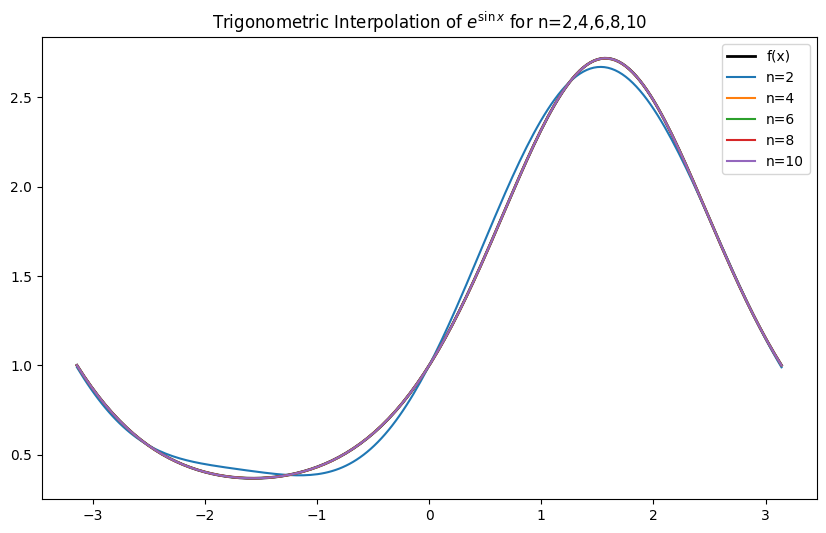

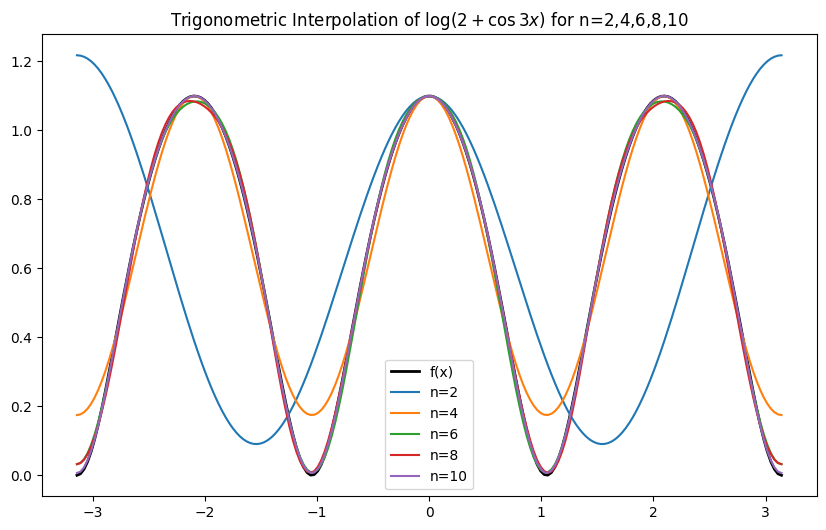

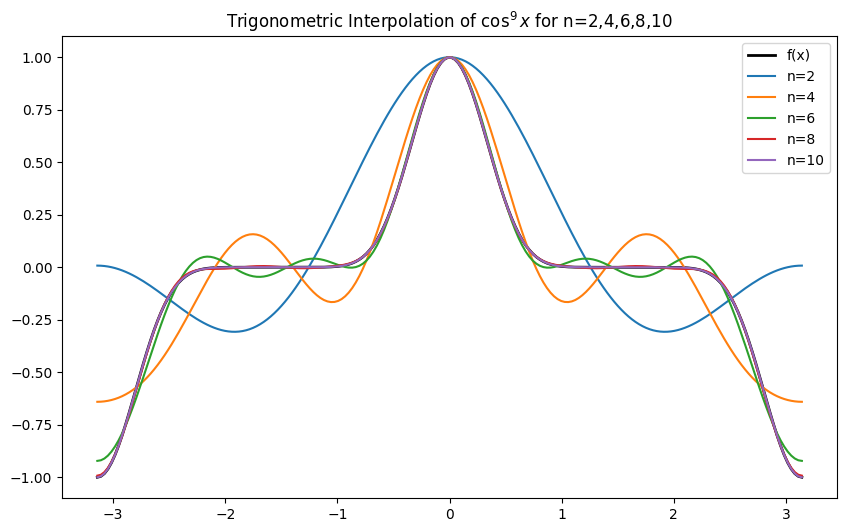

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def tau(x, N):
    out = np.ones_like(x) # Initialize output array with ones
    mask = np.abs(x) > 1e-14 # Avoid division by zero
    out[mask] = np.sin(N*x[mask]/2) / (N * np.sin(x[mask]/2)) # Compute tau values where x is not close to zero
    return out

def trig_interpolant(f, n, x):
    N = 2*n + 1 # Number of interpolation points

    k = np.arange(-n, n+1) # Indices for interpolation points
    xk = 2 * np.pi * k / N # Interpolation points
    yk = f(xk) # Data points

    p = np.zeros_like(x) # Initialize the interpolant array

    for j in range(len(k)): # Loop over each interpolation point
        p += yk[j] * tau(x - xk[j], N) # Add contribution of each interpolation point to the interpolant

    return p

# Functions to interpolate and their titles
f1 = lambda x: np.exp(np.sin(x))
f2 = lambda x: np.log(2 + np.cos(3*x))
f3 = lambda x: np.cos(x)**9

functions = [f1, f2, f3]
titles = [ r"$e^{\sin x}$", r"$\log(2 + \cos 3x)$", r"$\cos^9 x$"]

x = np.linspace(-np.pi, np.pi, 200) # Plotting dataset

for f, title in zip(functions, titles):
    plt.figure(figsize=(10, 6))

    plt.plot(x, f(x), 'k', linewidth=2, label='f(x)') # Original function

    for n in [2,4,6,8,10]:
        p = trig_interpolant(f, n, x) # Compute trig interpolant
        plt.plot(x, p, label=f'n={n}') # Plot interpolant

    plt.title(f'Trigonometric Interpolation of {title} for n=2,4,6,8,10')
    plt.legend()
    plt.show()

### Part (b)

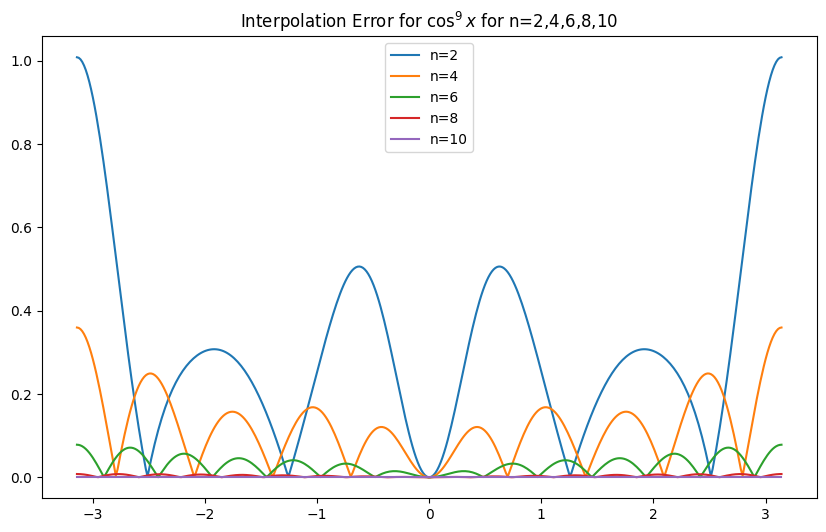

In [7]:
x = np.linspace(-np.pi, np.pi, 400)
f = lambda x: np.cos(x)**9

plt.figure(figsize=(10, 6))

for n in [2,4,6,8,10]:
    p = trig_interpolant(f, n, x) # Compute trig interpolant
    err = np.abs(f(x) - p) # Compute absolute error
    plt.plot(x, err, label=f'n={n}') # Plot interpolant

plt.title('Interpolation Error for $\\cos^9 x$ for n=2,4,6,8,10')
plt.legend()
plt.show()

Notice that $\cos^9 x$ is already a trigonometric polynomial of degree 9, since $$\cos^9 x = a_1 \cos x + a_3 \cos 3x + a_5 \cos 5x + a_7 \cos 7x + a_9 \cos 9x$$
so any interpolation with degree $n\geq 9$ will be exactly the same polynomial. The large error for small $n$ comes from the fact that the interpolating polynomial obviously doesn't match the function perfectly.

## Problem 3
Quadrature on non-equisapced nodes. We have $x_0 = a, x_1 = a + \frac{b-a}{3}, x_2 = b$. Let $h = \frac{b-a}{3}$, then shift the interval to $x_0 = 0, x_1 = h, x_2 = 3h$. We want
$$\int_0^{3h} f(x) dx \approx w_0 f(0) + w_1 f(h) + w_2 f(3h).$$
We require exactness for $1, x, x^2$

We match the constants $\int_0^{3h} 1 dx = 3h$, with $w_0 + w_1 + w_2 = 3h$. 

Matching the linear coefficients
$$\int_0^{3h} x dx = \frac{(3h)^2}{2} = \frac{9h^2}{2}$$
we get $0 \cdot w_0 + hw_1 + 3hw_2 = \frac{9h^2}{2}$, and divide by $h$ so $w_1 + 3w_2 = \frac{9h}{2}$. 

Matching the quadratic coefficients
$$\int_0^{3h} x^2 dx = \frac{(3h)^3}{3} = 9h^3$$
and get $0^2 w_0 + h^2 w_1 + 9h^2 w_2 = 9h^3$. Dividing by $h^2$, $w_1 + 9w_2 = 9h$.

Solving the system we get
$$(w_1 + 9w_2) - (w_1 + 3w_2) = 9h - \frac{9h}{2} \implies w_2 = \frac{3h}{4}.$$
Then
$$w_1 + 3(3h/4) = \frac{9h}{2} \implies w_1 = \frac{9h}{4}$$
so
$$w_0 = 3h - \frac{9h}{4} - \frac{3h}{4} = \frac{12h - 12h}{4} = 0$$

Finally
$$\int_a^b f(x) dx \approx \frac{3h}{4} \left[ 3f(a+h) + f(b) \right]$$
with $h=(b-a)/3$. 

We can check this numerically.

In [13]:
def quad_rule(f,a,b):
    h = (b-a)/3
    return (3*h/4)*(3*f(a+h) + f(b))

# test quadratic
f = lambda x: 2*x**2 - 3*x + 1

a,b = -1.2,2.3

exact = (2/3*b**3 - 3/2*b**2 + b) - (2/3*a**3 - 3/2*a**2 + a)
approx = quad_rule(f,a,b)

print("exact =", exact)
print("approx =", approx)

exact = 6.9883333333333315
approx = 6.9883333333333315


## Problem 4
Approximate $\int_{-0.5}^{1.5} \cos(x) dx$, which is exactly $\sin(1.5) - \sin(-0.5)$

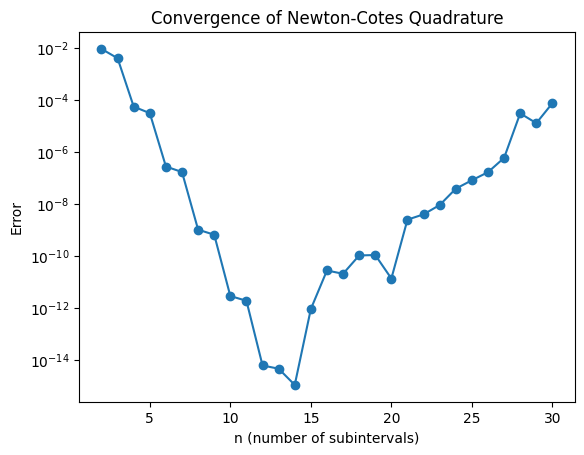

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import newton_cotes

f = np.cos

a, b = -0.5, 1.5

exact = np.sin(1.5) - np.sin(-0.5)

errors = []
ns = range(2, 31)

for n in ns:
    x = np.linspace(a, b, n+1)
    w,_ = newton_cotes(n)

    h = (b-a)/n

    approx = h * np.sum(w * f(x))
    errors.append(abs(approx - exact))

plt.semilogy(ns, errors, marker='o')
plt.xlabel('n (number of subintervals)')
plt.ylabel('Error')
plt.title('Convergence of Newton-Cotes Quadrature')
plt.show()

The error starts decreasing initially, then around $n=14$, starts increasing. This is because the weights become very large, alternate sign, and catestrophic cancellation occurs, causing error to explode for high n. High-degree interpolation on equispaced notes is ill-conditioned. 